<a href="https://colab.research.google.com/github/sanjay11082006/salivary-ferning-mobilenet-classification/blob/main/salivary_ferning_mobilenet_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Done!")
print("Fern images:", len(os.listdir('dataset/fern')))
print("No fern images:", len(os.listdir('dataset/no_fern')))

Saving dataset.zip to dataset.zip
Done!
Fern images: 30
No fern images: 59


Found 72 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
Class indices: {'fern': 0, 'no_fern': 1}
Training samples: 72
Validation samples: 17
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Phase 1: Training...
Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.4583 - loss: 0.8931 - val_accuracy: 0.7059 - val_loss: 0.5571
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.7083 - loss: 0.6298 - val_accuracy: 0.6471 - val_loss: 0.5247
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.7361 - loss: 0.4743 - val_accuracy: 0.7059 - val_loss: 0.4700
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.8889 - loss: 0.3363 - val_accuracy: 0.7647 - val_loss: 0.5173
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 378ms/step - accuracy: 0.8750 - loss: 0.3732 - val_accuracy: 0.7059 - val_loss: 0.5612
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.8333 - loss: 0.4155 - val_accuracy: 0.5882 - val_loss: 0.7254
Epoch 7/20

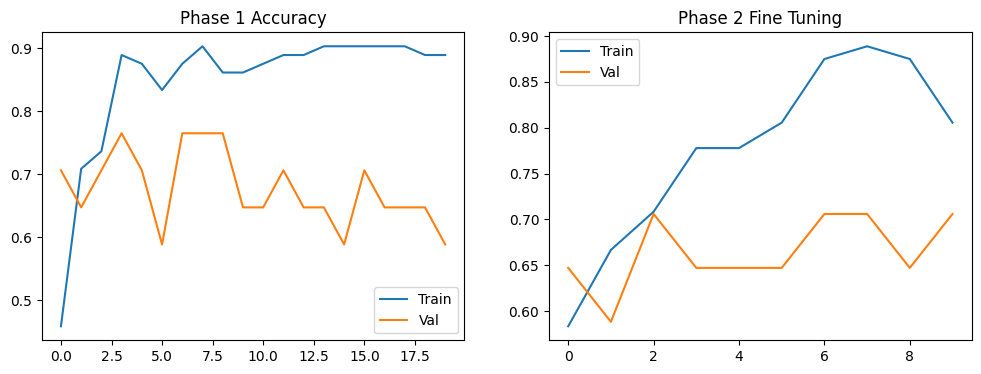

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7647 - loss: 0.5996 

FINAL ACCURACY: 76.47%
FINAL LOSS: 0.5996


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    'dataset/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='training',
    seed=42
)

val_data = datagen.flow_from_directory(
    'dataset/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='validation',
    seed=42
)

print("Class indices:", train_data.class_indices)
print("Training samples:", train_data.samples)
print("Validation samples:", val_data.samples)

# Load MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

# Add head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Phase 1 training
print("\nPhase 1: Training...")
history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    verbose=1
)

# Phase 2 fine tuning
print("\nPhase 2: Fine tuning...")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    verbose=1
)

# Plot
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Phase 1 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_fine.history['accuracy'], label='Train')
plt.plot(history_fine.history['val_accuracy'], label='Val')
plt.title('Phase 2 Fine Tuning')
plt.legend()
plt.show()

# Final result
loss, acc = model.evaluate(val_data)
print(f"\n{'='*40}")
print(f"FINAL ACCURACY: {acc*100:.2f}%")
print(f"FINAL LOSS: {loss:.4f}")
print(f"{'='*40}")

### 1. Advanced Evaluation Metrics
Accuracy can be misleading if the dataset is small or imbalanced. We use a Confusion Matrix and Classification Report to get a deeper look at the performance.

Found 17 images belonging to 2 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


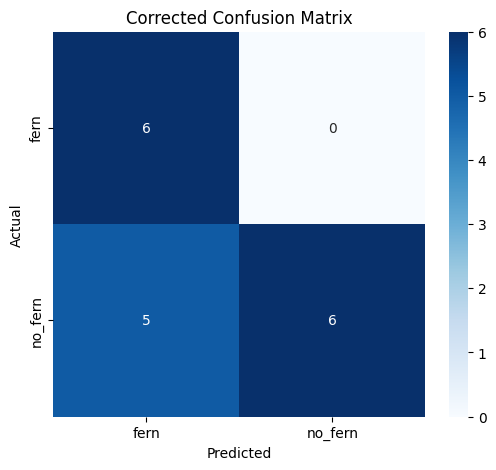


Classification Report (Corrected):
              precision    recall  f1-score   support

        fern       0.55      1.00      0.71         6
     no_fern       1.00      0.55      0.71        11

    accuracy                           0.71        17
   macro avg       0.77      0.77      0.71        17
weighted avg       0.84      0.71      0.71        17



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Re-create val_data without shuffling for accurate evaluation
eval_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
eval_val_data = eval_datagen.flow_from_directory(
    'dataset/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

# Get correct predictions
y_pred_probs = model.predict(eval_val_data)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = eval_val_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=eval_val_data.class_indices.keys(),
            yticklabels=eval_val_data.class_indices.keys())
plt.title('Corrected Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print('\nClassification Report (Corrected):')
print(classification_report(y_true, y_pred, target_names=eval_val_data.class_indices.keys()))

### 2. Single Image Inference
Use this cell to test the model on a single image file. The function will automatically load the saved model if it isn't currently in memory.

In [18]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

def predict_image(img_path):
    global model
    # If model is not in memory, try to load it from the saved file
    if 'model' not in globals():
        if os.path.exists('fern_model.keras'):
            print("Model variable not found. Loading from 'fern_model.keras'...")
            model = tf.keras.models.load_model('fern_model.keras')
        else:
            print("Error: The 'model' variable is not defined and 'fern_model.keras' was not found.")
            return

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]
    class_name = "No Fern" if prediction > 0.5 else "Fern"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    plt.imshow(img)
    plt.title(f"Prediction: {class_name} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

### 3. Test with Your Own Image
Run this cell to upload an image and see if the model identifies it as a **Fern** or **No Fern**.

Saving images.jpg to images.jpg
User uploaded file "images.jpg"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


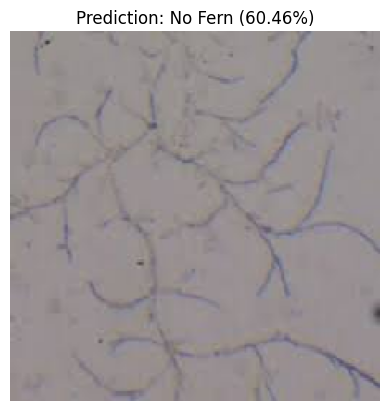

In [40]:
from google.colab import files

uploaded_test = files.upload()

for fn in uploaded_test.keys():
    print(f'User uploaded file "{fn}"')
    predict_image(fn)

### 4. Save and Download Model
This cell saves the trained model to the Colab environment and triggers a download to your local machine.

In [38]:
# Save the model
model.save('fern_model.keras')
print("Model saved as fern_model.keras")

# Download to local computer
from google.colab import files
files.download('fern_model.keras')

Model saved as fern_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>